In [71]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap

In [72]:
from google.colab import files
uploaded = files.upload()
iris_df = pd.read_csv("Iris.csv")
iris_df.drop(columns=["Id"], inplace=True)
iris_X = iris_df.iloc[:, 0:2].values  # Only first 2 features for 2D plotting
iris_y = iris_df.iloc[:, -1].values

Saving database.sqlite to database (2).sqlite
Saving Iris.csv to Iris (5).csv


In [73]:
# Encode labels
iris_encoder = LabelEncoder()
iris_y_encoded = iris_encoder.fit_transform(iris_y)


In [74]:
# Normalize
scaler1 = StandardScaler()
iris_X_scaled = scaler1.fit_transform(iris_X)

In [75]:
# Split
X_train, X_test, y_train, y_test = train_test_split(iris_X_scaled, iris_y_encoded, test_size=0.2, random_state=42)

In [76]:
# Train KNN
knn_iris = KNeighborsClassifier(n_neighbors=3)
knn_iris.fit(X_train, y_train)
y_pred = knn_iris.predict(X_test)

In [77]:
# Train KNN
knn_iris = KNeighborsClassifier(n_neighbors=3)
knn_iris.fit(X_train, y_train)
y_pred = knn_iris.predict(X_test)


In [78]:
print("\n=== Iris.csv KNN Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


=== Iris.csv KNN Results ===
Accuracy: 0.8333333333333334
Confusion Matrix:
 [[10  0  0]
 [ 0  6  3]
 [ 0  2  9]]


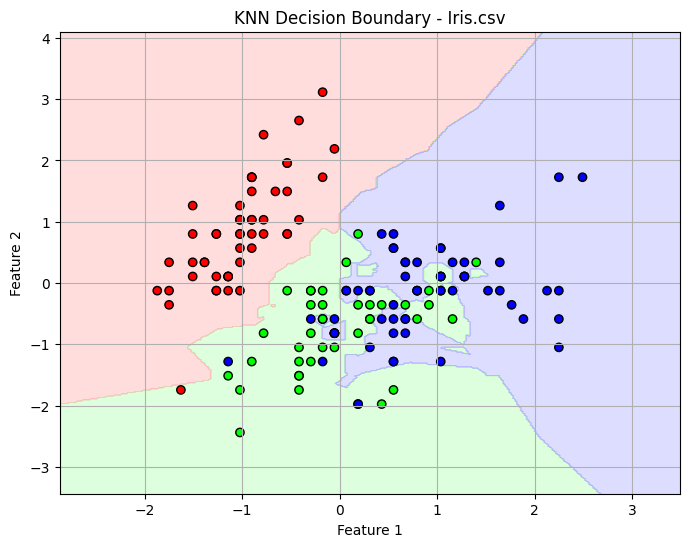

In [79]:
# Plot decision boundaries
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF']))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF0000','#00FF00','#0000FF']), edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(iris_X_scaled, iris_y_encoded, knn_iris, "KNN Decision Boundary - Iris.csv")